In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
DATA_DIR = "/content/drive/MyDrive/Vivek"
os.listdir(DATA_DIR)

['Phishing_validation_emails.csv',
 'Nigerian_Fraud.csv',
 'Nazario.csv',
 'enron_mail_20150507.tar.gz']

In [3]:
DATA_DIR = "/content/drive/MyDrive/Vivek"

!cp "{DATA_DIR}/Nazario.csv" /content/
!cp "{DATA_DIR}/Nigerian_Fraud.csv" /content/
!cp "{DATA_DIR}/Phishing_validation_emails.csv" /content/
!cp "{DATA_DIR}/enron_mail_20150507.tar.gz" /content/
!ls -lh

total 440M
drwx------ 5 root root 4.0K Apr 10 08:11 drive
-rw------- 1 root root 423M Apr 10 08:12 enron_mail_20150507.tar.gz
-rw------- 1 root root 7.5M Apr 10 08:11 Nazario.csv
-rw------- 1 root root 8.8M Apr 10 08:12 Nigerian_Fraud.csv
-rw------- 1 root root 199K Apr 10 08:12 Phishing_validation_emails.csv
drwxr-xr-x 1 root root 4.0K Mar 30 13:34 sample_data


In [4]:
!tar -xzf /content/enron_mail_20150507.tar.gz
!ls

drive			    Nazario.csv			    sample_data
enron_mail_20150507.tar.gz  Nigerian_Fraud.csv
maildir			    Phishing_validation_emails.csv


In [5]:

# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# =========================
# DATA LOADING & STRUCTURE INSPECTION
# =========================
naz = pd.read_csv("/content/Nazario.csv")
nig = pd.read_csv("/content/Nigerian_Fraud.csv")
ext = pd.read_csv("/content/Phishing_validation_emails.csv")

print("Nazario shape:", naz.shape)
print("Nazario columns:", list(naz.columns))

print("\nNigerian_Fraud shape:", nig.shape)
print("Nigerian_Fraud columns:", list(nig.columns))

print("\nExternal validation shape:", ext.shape)
print("External validation columns:", list(ext.columns))

Nazario shape: (1565, 7)
Nazario columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

Nigerian_Fraud shape: (3332, 7)
Nigerian_Fraud columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

External validation shape: (2000, 2)
External validation columns: ['Email Text', 'Email Type']


In [7]:
# =========================
# BUILD HAM DATASET FROM ENRON (EMAIL PARSING)
# =========================
import glob, random, email
from email import policy
from tqdm import tqdm

def parse_email_file(path):
    try:
        with open(path, "rb") as f:
            msg = email.message_from_binary_file(f, policy=policy.default)
        subject = msg.get("subject", "")
        body = ""
        if msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == "text/plain":
                    body += str(part.get_content())
        else:
            body = str(msg.get_content())
        return (str(subject) + "\n" + str(body)).strip()
    except:
        return ""

ENRON_ROOT = "/content/maildir"
all_files = [p for p in glob.glob(ENRON_ROOT + "/**/*", recursive=True) if os.path.isfile(p)]
print("Total Enron files found:", len(all_files))

random.seed(42)
sample_files = random.sample(all_files, k=min(15000, len(all_files)))

ham_rows = []
for fp in tqdm(sample_files):
    text = parse_email_file(fp)
    if len(text) > 30:
        ham_rows.append({"text": text, "label": 0, "source": "enron_ham"})

ham_df = pd.DataFrame(ham_rows)
print("Ham dataset shape:", ham_df.shape)
ham_df.head()

Total Enron files found: 517401


100%|██████████| 15000/15000 [00:15<00:00, 986.80it/s]


Ham dataset shape: (14883, 3)


,text,label,source
0,Re: California Lawmakers Vote to Limit Power C...,0,enron_ham
1,Re: Outline for Project on Real-Time Markets\n...,0,enron_ham
2,storage schedules\nChris - I wasn't sure who t...,0,enron_ham
3,FW: Agency Form\n -----Original Message-----\n...,0,enron_ham
4,Expense Report for Stephen Schwarz Dated 4/13/...,0,enron_ham


### Data Preprocessing & Cleaning

In [8]:
# =========================
#  BUILD PHISHING TRAINING DATASET (NAZARIO + NIGERIAN_FRAUD)
# =========================

# Combining both phishing datasets
phish_raw = pd.concat([naz, nig], ignore_index=True)

# Creating a single text field: subject + body + urls
phish_raw["subject"] = phish_raw["subject"].fillna("").astype(str)
phish_raw["body"] = phish_raw["body"].fillna("").astype(str)
phish_raw["urls"] = phish_raw["urls"].fillna("").astype(str)

phish_raw["text"] = (phish_raw["subject"] + "\n" + phish_raw["body"] + "\n" + phish_raw["urls"]).str.strip()

# Keeping only relevant columns
phish_df = phish_raw[["text"]].copy()
phish_df["label"] = 1
phish_df["source"] = "phish_train"

# Removing very short rows
phish_df = phish_df[phish_df["text"].str.len() > 30].reset_index(drop=True)

print("Phishing dataset shape:", phish_df.shape)
phish_df.head()

Phishing dataset shape: (4896, 3)


,text,label,source
0,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL D...,1,phish_train
1,Verify Your Account\nBusiness with \t\t\t\t\t...,1,phish_train
2,Helpdesk Mailbox Alert!!!\nYour two incoming m...,1,phish_train
3,IT-Service Help Desk\nPassword will expire in ...,1,phish_train
4,Final USAA Reminder - Update Your Account Now\...,1,phish_train


In [9]:
# =========================
#  COMBINE HAM + PHISHING INTO TRAINING POOL
# =========================

train_pool = pd.concat([ham_df, phish_df], ignore_index=True)

print("Combined dataset shape:", train_pool.shape)
print("\nClass counts:")
print(train_pool["label"].value_counts())
print("\nSource counts:")
print(train_pool["source"].value_counts())

Combined dataset shape: (19779, 3)

Class counts:
label
0    14883
1     4896
Name: count, dtype: int64

Source counts:
source
enron_ham      14883
phish_train     4896
Name: count, dtype: int64


In [10]:
# =========================
#  DATA PREPROCESSING & CLEANING
# =========================

# 1) Removing duplicates
train_pool["text"] = train_pool["text"].astype(str)
train_pool["text"] = train_pool["text"].str.replace(r"\s+", " ", regex=True).str.strip()

before = train_pool.shape[0]
train_pool = train_pool.drop_duplicates(subset=["text"]).reset_index(drop=True)
after = train_pool.shape[0]

print("Rows before dedup:", before)
print("Rows after dedup :", after)

# 2) Removing empty/very short samples
train_pool = train_pool[train_pool["text"].str.len() > 30].reset_index(drop=True)

# 3) Adding basic text stats for EDA
train_pool["char_len"] = train_pool["text"].str.len()
train_pool["word_len"] = train_pool["text"].str.split().apply(len)

print("\nFinal training pool shape:", train_pool.shape)
train_pool.head()

Rows before dedup: 19779
Rows after dedup : 19109

Final training pool shape: (19109, 5)


,text,label,source,char_len,word_len
0,Re: California Lawmakers Vote to Limit Power C...,0,enron_ham,3815,592
1,Re: Outline for Project on Real-Time Markets C...,0,enron_ham,5464,801
2,storage schedules Chris - I wasn't sure who to...,0,enron_ham,633,94
3,FW: Agency Form -----Original Message----- Fro...,0,enron_ham,700,76
4,Expense Report for Stephen Schwarz Dated 4/13/...,0,enron_ham,765,100


### EDA

In [11]:
# =========================
# EDA - DATASET OVERVIEW
# =========================

print("Final dataset shape:", train_pool.shape)
print("\nClass distribution:")
print(train_pool["label"].value_counts())

print("\nClass distribution (%):")
print((train_pool["label"].value_counts(normalize=True)*100).round(2))

print("\nText length summary (characters):")
print(train_pool.groupby("label")["char_len"].describe())

print("\nText length summary (words):")
print(train_pool.groupby("label")["word_len"].describe())

Final dataset shape: (19109, 5)

Class distribution:
label
0    14265
1     4844
Name: count, dtype: int64

Class distribution (%):
label
0    74.65
1    25.35
Name: proportion, dtype: float64

Text length summary (characters):
         count         mean           std   min      25%     50%     75%  \
label                                                                      
0      14265.0  1790.893445   6083.005186  31.0   306.00   762.0  1724.0   
1       4844.0  3293.013832  67158.595436  36.0  1003.75  2058.5  2960.0   

             max  
label             
0       319026.0  
1      4560763.0  

Text length summary (words):
         count        mean          std  min    25%    50%     75%       max
label                                                                       
0      14265.0  269.141535   939.020217  1.0   49.0  118.0  261.00   52224.0
1       4844.0  393.165979  1982.445984  3.0  158.0  346.0  502.25  127128.0


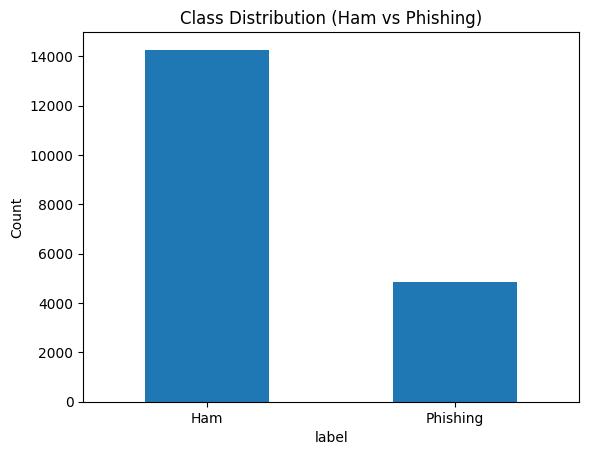

In [12]:
# =========================
# EDA - CLASS DISTRIBUTION PLOT
# =========================
import matplotlib.pyplot as plt

plt.figure()
train_pool["label"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Ham", "Phishing"], rotation=0)
plt.title("Class Distribution (Ham vs Phishing)")
plt.ylabel("Count")
plt.show()

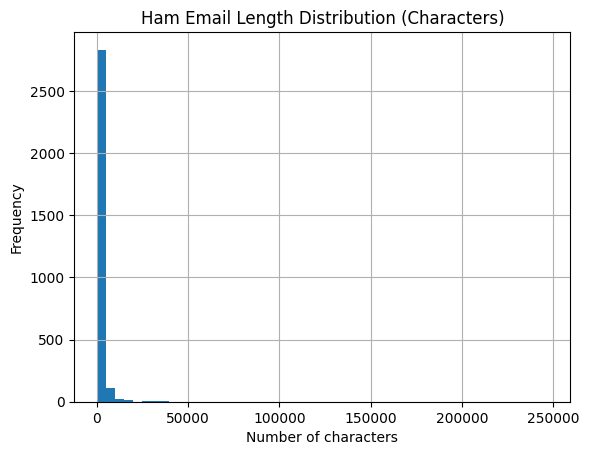

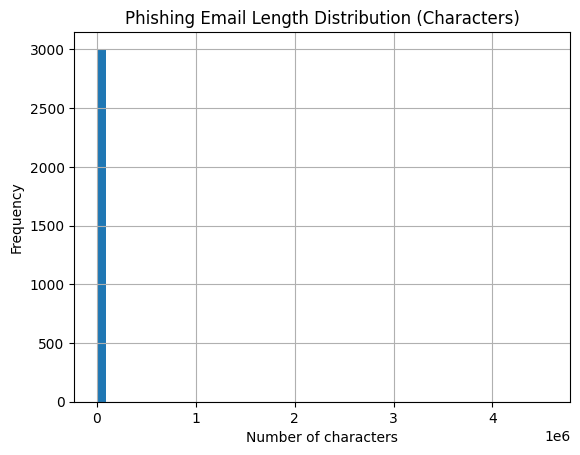

In [13]:
# =========================
# EDA - LENGTH DISTRIBUTION (CHARACTERS)
# =========================

plt.figure()
train_pool[train_pool["label"]==0]["char_len"].sample(min(3000, (train_pool["label"]==0).sum()), random_state=42).hist(bins=50)
plt.title("Ham Email Length Distribution (Characters)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

plt.figure()
train_pool[train_pool["label"]==1]["char_len"].sample(min(3000, (train_pool["label"]==1).sum()), random_state=42).hist(bins=50)
plt.title("Phishing Email Length Distribution (Characters)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

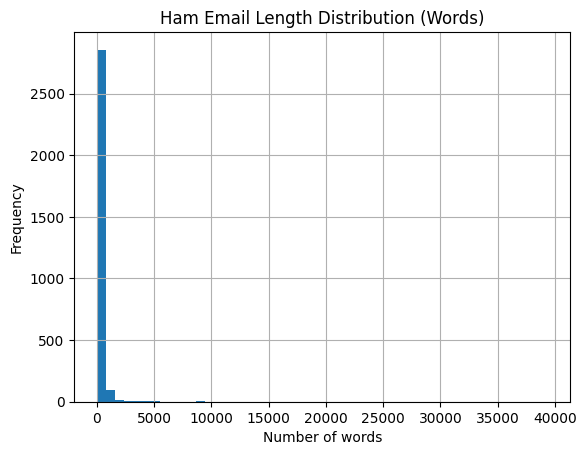

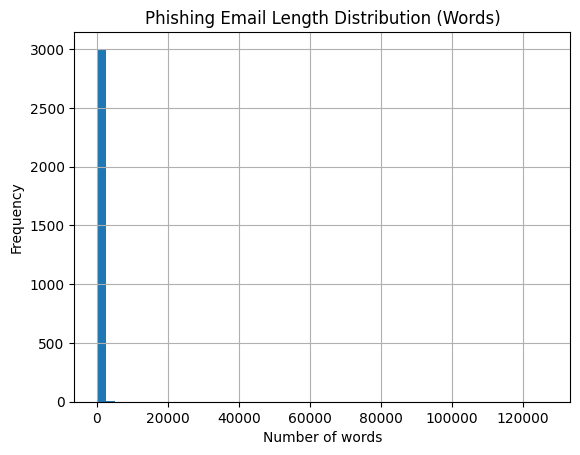

In [14]:
# =========================
#EDA - LENGTH DISTRIBUTION (WORDS)
# =========================

plt.figure()
train_pool[train_pool["label"]==0]["word_len"].sample(min(3000, (train_pool["label"]==0).sum()), random_state=42).hist(bins=50)
plt.title("Ham Email Length Distribution (Words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

plt.figure()
train_pool[train_pool["label"]==1]["word_len"].sample(min(3000, (train_pool["label"]==1).sum()), random_state=42).hist(bins=50)
plt.title("Phishing Email Length Distribution (Words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

<Figure size 640x480 with 0 Axes>

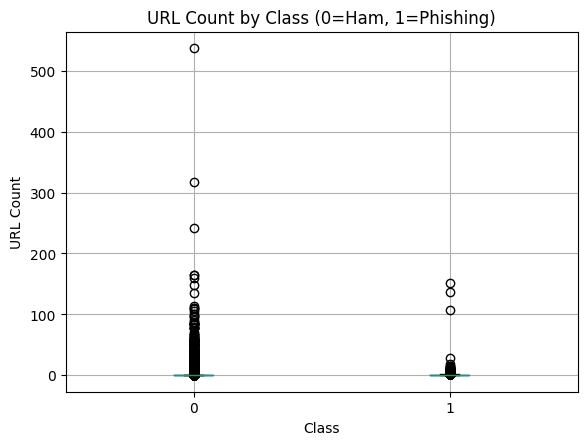

In [15]:
# =========================
# EDA - URL COUNT COMPARISON
# =========================
import re

def count_urls(text):
    return len(re.findall(r"http[s]?://|www\.", str(text).lower()))

train_pool["url_count"] = train_pool["text"].apply(count_urls)

plt.figure()
train_pool.boxplot(column="url_count", by="label")
plt.title("URL Count by Class (0=Ham, 1=Phishing)")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("URL Count")
plt.show()

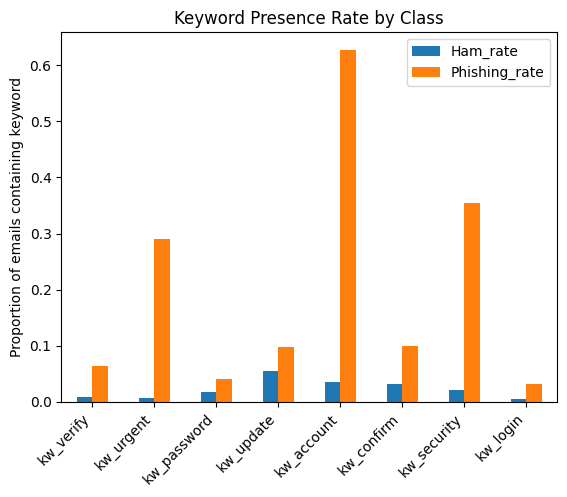

,Ham_rate,Phishing_rate
kw_verify,0.007992,0.064822
kw_urgent,0.007291,0.290875
kw_password,0.017175,0.041495
kw_update,0.054609,0.098679
kw_account,0.035121,0.627374
kw_confirm,0.031616,0.099917
kw_security,0.021311,0.354253
kw_login,0.005678,0.031379


In [16]:
# =========================
# EDA - URGENCY KEYWORDS (PHISHING SIGNAL)
# =========================

keywords = ["verify", "urgent", "password", "update", "account", "confirm", "security", "login"]

for kw in keywords:
    train_pool[f"kw_{kw}"] = train_pool["text"].str.lower().str.contains(rf"\b{kw}\b", regex=True)

kw_rates = train_pool.groupby("label")[[f"kw_{k}" for k in keywords]].mean().T
kw_rates.columns = ["Ham_rate", "Phishing_rate"]

kw_rates.plot(kind="bar")
plt.title("Keyword Presence Rate by Class")
plt.ylabel("Proportion of emails containing keyword")
plt.xticks(rotation=45, ha="right")
plt.show()

kw_rates

In [17]:
# =========================
# EDA - TOP WORDS BY CLASS
# =========================
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def get_top_words(texts, n=15):
    vec = CountVectorizer(stop_words="english", max_features=8000)
    X = vec.fit_transform(texts)
    sums = np.asarray(X.sum(axis=0)).flatten()
    words = vec.get_feature_names_out()
    top_idx = np.argsort(sums)[::-1][:n]
    return pd.DataFrame({"word": words[top_idx], "count": sums[top_idx]})

ham_sample = train_pool[train_pool["label"]==0]["text"].sample(min(4000, (train_pool["label"]==0).sum()), random_state=42)
phish_sample = train_pool[train_pool["label"]==1]["text"].sample(min(4000, (train_pool["label"]==1).sum()), random_state=42)

ham_top = get_top_words(ham_sample)
phish_top = get_top_words(phish_sample)

print("Top words in Ham:")
display(ham_top)

print("Top words in Phishing:")
display(phish_top)

Top words in Ham:


,word,count
0,enron,12515
1,com,11994
2,ect,8082
3,2001,4022
4,hou,3785
5,subject,3412
6,energy,3367
7,power,3351
8,01,2965
9,said,2929


Top words in Phishing:


,word,count
0,com,35239
1,account,10606
2,money,8405
3,hotmail,7810
4,bank,6923
5,aol,6477
6,net,5773
7,yahoo,5728
8,email,5473
9,org,4461


Train / Validation / Test Split

In [18]:
# =========================
# SECTION 13: INTERNAL SPLIT (TRAIN / VAL / TEST)
# =========================
from sklearn.model_selection import train_test_split

X = train_pool["text"].values
y = train_pool["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train size:", len(X_train))
print("Val size  :", len(X_val))
print("Test size :", len(X_test))

Train size: 13376
Val size  : 2866
Test size : 2867


TF–IDF Feature Extraction

In [19]:
# =========================
# SECTION 14: TF–IDF FEATURE EXTRACTION
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    stop_words="english"
)

Xtr = tfidf.fit_transform(X_train)
Xva = tfidf.transform(X_val)
Xte = tfidf.transform(X_test)

print("TF–IDF Train matrix:", Xtr.shape)
print("TF–IDF Val matrix  :", Xva.shape)
print("TF–IDF Test matrix :", Xte.shape)

TF–IDF Train matrix: (13376, 50000)
TF–IDF Val matrix  : (2866, 50000)
TF–IDF Test matrix : (2867, 50000)


MODEL TRAINING

In [20]:
# =========================
# SECTION 15A: BASELINE MODEL TRAINING
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=3000, class_weight="balanced")
svm = LinearSVC(class_weight="balanced")
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

lr.fit(Xtr, y_train)
svm.fit(Xtr, y_train)
rf.fit(Xtr, y_train)

print(" Baseline models trained: Logistic Regression, Linear SVM, Random Forest")


 Baseline models trained: Logistic Regression, Linear SVM, Random Forest


In [21]:
# =========================
# SECTION 16A: EVALUATION FUNCTION
# =========================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

def get_scores(model, Xmat):
    """Return probability-like scores for ROC/PR curves."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(Xmat)[:, 1]
    return model.decision_function(Xmat)

def plot_confusion_matrix(cm, class_names, title):
    """Simple Matplotlib confusion matrix plot (no seaborn)."""
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=0)
    plt.yticks(tick_marks, class_names)


    thresh = cm.max() / 2.0 if cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

def evaluate_model(name, model, Xmat, y_true):
    scores = get_scores(model, Xmat)

    # Predictions
    if hasattr(model, "predict_proba"):
        y_pred = model.predict(Xmat)
    else:
        y_pred = (scores >= 0).astype(int)  # threshold at 0 for LinearSVC scores

    print("\n==============================")
    print(f"MODEL: {name}")
    print("==============================")
    print(classification_report(y_true, y_pred, target_names=["Ham", "Phishing"]))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)
    plot_confusion_matrix(cm, ["Ham", "Phishing"], f"Confusion Matrix - {name}")

    # AUC metrics
    roc = roc_auc_score(y_true, scores)
    pr  = average_precision_score(y_true, scores)

    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC (Average Precision): {pr:.4f}")

    return scores, y_pred, cm


MODEL: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      2140
    Phishing       1.00      0.99      0.99       727

    accuracy                           1.00      2867
   macro avg       1.00      0.99      1.00      2867
weighted avg       1.00      1.00      1.00      2867

Confusion Matrix:
 [[2138    2]
 [   7  720]]


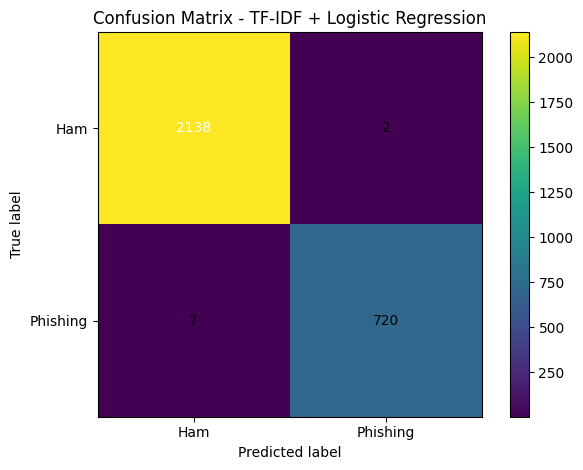

ROC-AUC: 0.9994
PR-AUC (Average Precision): 0.9989

MODEL: TF-IDF + Linear SVM
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      2140
    Phishing       1.00      0.99      0.99       727

    accuracy                           1.00      2867
   macro avg       1.00      0.99      1.00      2867
weighted avg       1.00      1.00      1.00      2867

Confusion Matrix:
 [[2139    1]
 [   7  720]]


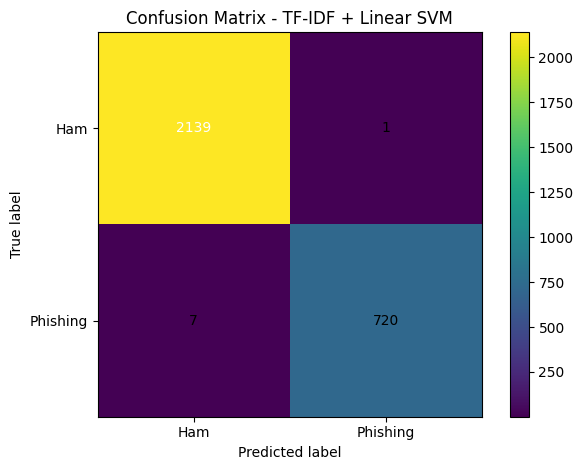

ROC-AUC: 0.9997
PR-AUC (Average Precision): 0.9994

MODEL: TF-IDF + Random Forest
              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00      2140
    Phishing       1.00      0.98      0.99       727

    accuracy                           1.00      2867
   macro avg       1.00      0.99      0.99      2867
weighted avg       1.00      1.00      1.00      2867

Confusion Matrix:
 [[2140    0]
 [  11  716]]


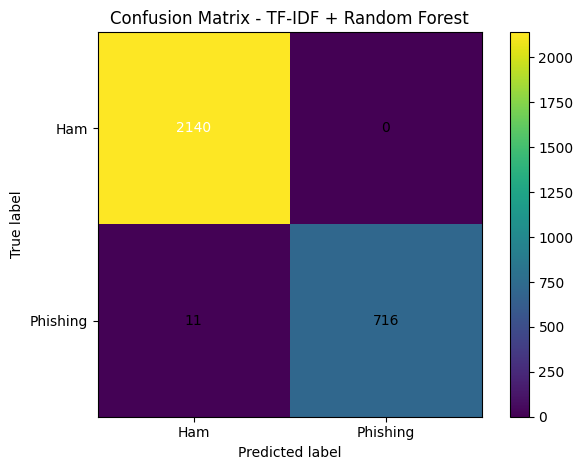

ROC-AUC: 0.9994
PR-AUC (Average Precision): 0.9986


In [22]:
# =========================
# SECTION 16B: BASELINE EVALUATION ON TEST SET
# =========================
scores_lr, pred_lr, cm_lr   = evaluate_model("TF-IDF + Logistic Regression", lr, Xte, y_test)
scores_svm, pred_svm, cm_svm = evaluate_model("TF-IDF + Linear SVM", svm, Xte, y_test)
scores_rf, pred_rf, cm_rf   = evaluate_model("TF-IDF + Random Forest", rf, Xte, y_test)

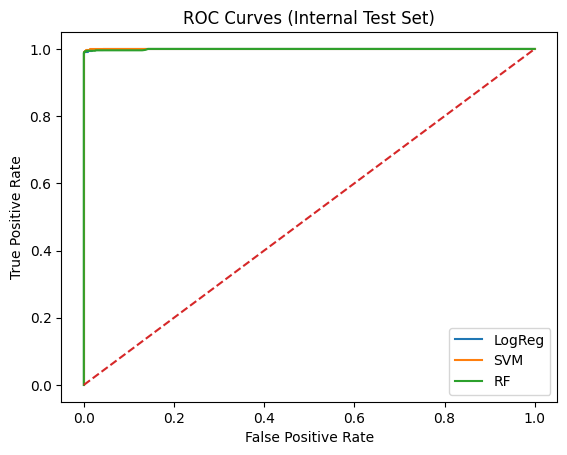

In [23]:
# =========================
# SECTION 17A: ROC CURVES
# =========================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure()
for name, scores in [("LogReg", scores_lr), ("SVM", scores_svm), ("RF", scores_rf)]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves (Internal Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

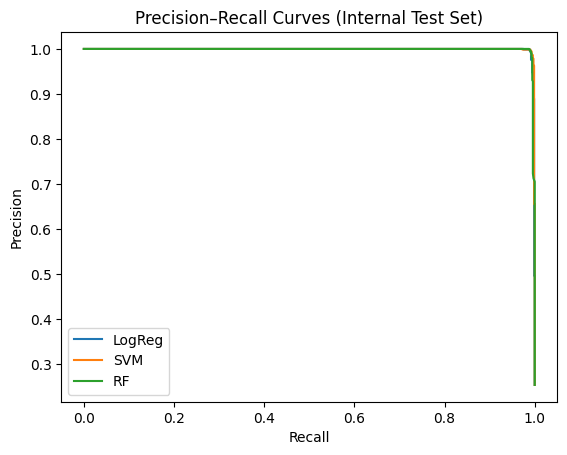

In [24]:
# =========================
# SECTION 17B: PRECISION–RECALL CURVES
# =========================
from sklearn.metrics import precision_recall_curve

plt.figure()
for name, scores in [("LogReg", scores_lr), ("SVM", scores_svm), ("RF", scores_rf)]:
    prec, rec, _ = precision_recall_curve(y_test, scores)
    plt.plot(rec, prec, label=name)

plt.title("Precision–Recall Curves (Internal Test Set)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [25]:
# =========================
# SECTION 18: RESULTS SUMMARY TABLE
# =========================
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def summary_row(name, y_true, y_pred, scores):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, scores),
        "PR_AUC": average_precision_score(y_true, scores)
    }

results_table = pd.DataFrame([
    summary_row("TF–IDF + Logistic Regression", y_test, pred_lr, scores_lr),
    summary_row("TF–IDF + Linear SVM", y_test, pred_svm, scores_svm),
    summary_row("TF–IDF + Random Forest", y_test, pred_rf, scores_rf),
])

results_table

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,TF–IDF + Logistic Regression,0.996861,0.997230,0.990371,0.993789,0.999380,0.998906
1,TF–IDF + Linear SVM,0.997210,0.998613,0.990371,0.994475,0.999701,0.999370
2,TF–IDF + Random Forest,0.996163,1.000000,0.984869,0.992377,0.999379,0.998638


In [26]:
# =========================
# SECTION 20: LOAD EXTERNAL VALIDATION DATASET
# =========================
import pandas as pd

ext = pd.read_csv("/content/Phishing_validation_emails.csv")
print(ext.shape)
print(ext.columns)
ext.head()

(2000, 2)
Index(['Email Text', 'Email Type'], dtype='object')


,Email Text,Email Type
0,"Dear Jordan, your subscription has been succes...",Safe Email
1,"Dear Casey, thank you for your purchase. Your ...",Safe Email
2,Congratulations! You've won a $3000 gift card....,Phishing Email
3,You have a new secure message from your bank. ...,Phishing Email
4,Your package delivery is pending. Please provi...,Phishing Email


In [27]:
# =========================
# SECTION 20.1: MAP LABELS + TRANSFORM USING TF-IDF
# =========================
ext["Email Type"] = ext["Email Type"].astype(str).str.strip().str.lower()
ext["label"] = ext["Email Type"].apply(lambda x: 1 if "phish" in x else 0)
ext["text"] = ext["Email Text"].astype(str)

X_ext = ext["text"].values
y_ext = ext["label"].values

X_ext_tfidf = tfidf.transform(X_ext)

print("External class counts:")
print(pd.Series(y_ext).value_counts())

External class counts:
0    1000
1    1000
Name: count, dtype: int64



MODEL: EXTERNAL: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

         Ham       0.71      0.99      0.82      1000
    Phishing       0.98      0.59      0.74      1000

    accuracy                           0.79      2000
   macro avg       0.85      0.79      0.78      2000
weighted avg       0.85      0.79      0.78      2000

Confusion Matrix:
 [[990  10]
 [410 590]]


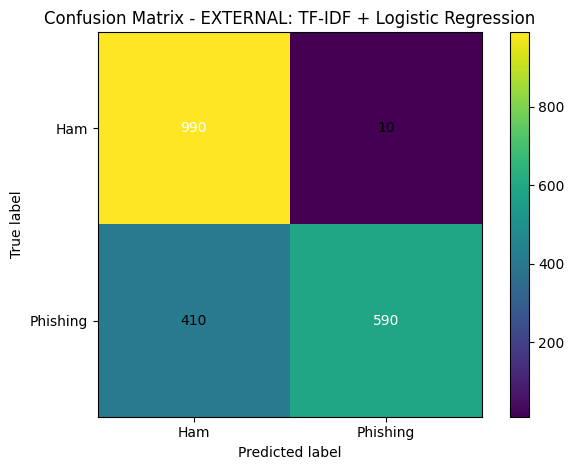

ROC-AUC: 0.8939
PR-AUC (Average Precision): 0.9049

MODEL: EXTERNAL: TF-IDF + Linear SVM
              precision    recall  f1-score   support

         Ham       0.66      0.81      0.73      1000
    Phishing       0.76      0.59      0.66      1000

    accuracy                           0.70      2000
   macro avg       0.71      0.70      0.70      2000
weighted avg       0.71      0.70      0.70      2000

Confusion Matrix:
 [[812 188]
 [410 590]]


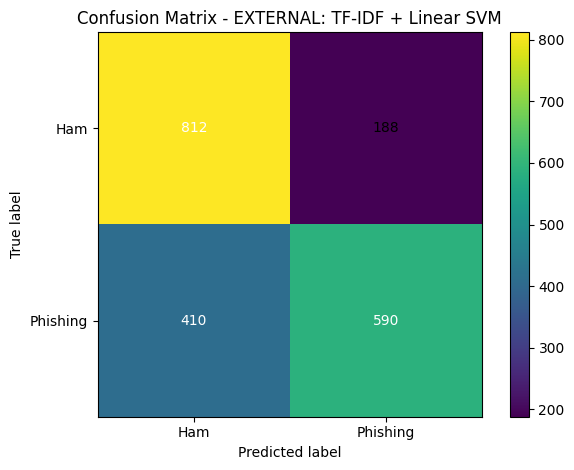

ROC-AUC: 0.9033
PR-AUC (Average Precision): 0.9103

MODEL: EXTERNAL: TF-IDF + Random Forest
              precision    recall  f1-score   support

         Ham       0.58      1.00      0.74      1000
    Phishing       1.00      0.28      0.44      1000

    accuracy                           0.64      2000
   macro avg       0.79      0.64      0.59      2000
weighted avg       0.79      0.64      0.59      2000

Confusion Matrix:
 [[1000    0]
 [ 716  284]]


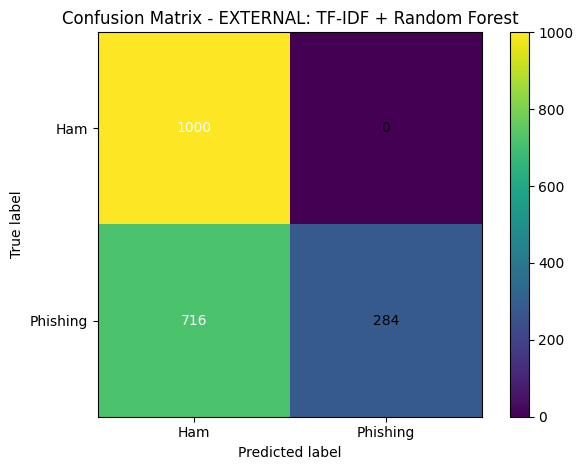

ROC-AUC: 0.8599
PR-AUC (Average Precision): 0.8485


In [28]:
# =========================
# SECTION 20.2: EXTERNAL VALIDATION EVALUATION
# =========================
scores_lr_ext, pred_lr_ext, cm_lr_ext = evaluate_model("EXTERNAL: TF-IDF + Logistic Regression", lr, X_ext_tfidf, y_ext)
scores_svm_ext, pred_svm_ext, cm_svm_ext = evaluate_model("EXTERNAL: TF-IDF + Linear SVM", svm, X_ext_tfidf, y_ext)
scores_rf_ext, pred_rf_ext, cm_rf_ext = evaluate_model("EXTERNAL: TF-IDF + Random Forest", rf, X_ext_tfidf, y_ext)

In [29]:
# =========================
# SECTION 22: INTERNAL vs EXTERNAL SUMMARY TABLE
# =========================
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def metric_row(name, y_true, y_pred, scores, split):
    return {
        "Split": split,
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, scores),
        "PR_AUC": average_precision_score(y_true, scores)
    }

summary_df = pd.DataFrame([
    # INTERNAL
    metric_row("TF-IDF + Logistic Regression", y_test, pred_lr, scores_lr, "Internal Test"),
    metric_row("TF-IDF + Linear SVM", y_test, pred_svm, scores_svm, "Internal Test"),
    metric_row("TF-IDF + Random Forest", y_test, pred_rf, scores_rf, "Internal Test"),

    # EXTERNAL
    metric_row("TF-IDF + Logistic Regression", y_ext, pred_lr_ext, scores_lr_ext, "External Test"),
    metric_row("TF-IDF + Linear SVM", y_ext, pred_svm_ext, scores_svm_ext, "External Test"),
    metric_row("TF-IDF + Random Forest", y_ext, pred_rf_ext, scores_rf_ext, "External Test"),
])

summary_df

,Split,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Internal Test,TF-IDF + Logistic Regression,0.996861,0.997230,0.990371,0.993789,0.999380,0.998906
1,Internal Test,TF-IDF + Linear SVM,0.997210,0.998613,0.990371,0.994475,0.999701,0.999370
2,Internal Test,TF-IDF + Random Forest,0.996163,1.000000,0.984869,0.992377,0.999379,0.998638
3,External Test,TF-IDF + Logistic Regression,0.790000,0.983333,0.590000,0.737500,0.893907,0.904934
4,External Test,TF-IDF + Linear SVM,0.701000,0.758355,0.590000,0.663667,0.903253,0.910329
5,External Test,TF-IDF + Random Forest,0.642000,1.000000,0.284000,0.442368,0.859910,0.848494


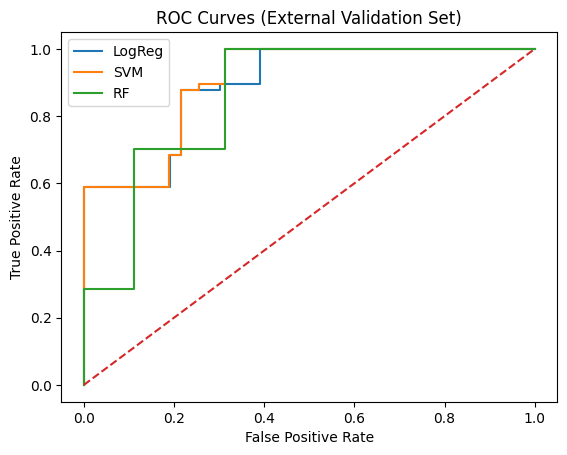

In [30]:
# =========================
# SECTION 23: EXTERNAL ROC CURVES
# =========================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure()
for name, scores in [("LogReg", scores_lr_ext), ("SVM", scores_svm_ext), ("RF", scores_rf_ext)]:
    fpr, tpr, _ = roc_curve(y_ext, scores)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves (External Validation Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [31]:
# =========================
# SECTION 24: SAVE FINAL TABLES
# =========================
summary_df.to_csv("internal_external_results_summary.csv", index=False)


internal_only = summary_df[summary_df["Split"]=="Internal Test"].reset_index(drop=True)
internal_only.to_csv("internal_baseline_results_only.csv", index=False)

print("Saved files:")
print("- internal_external_results_summary.csv")
print("- internal_baseline_results_only.csv")

Saved files:
- internal_external_results_summary.csv
- internal_baseline_results_only.csv


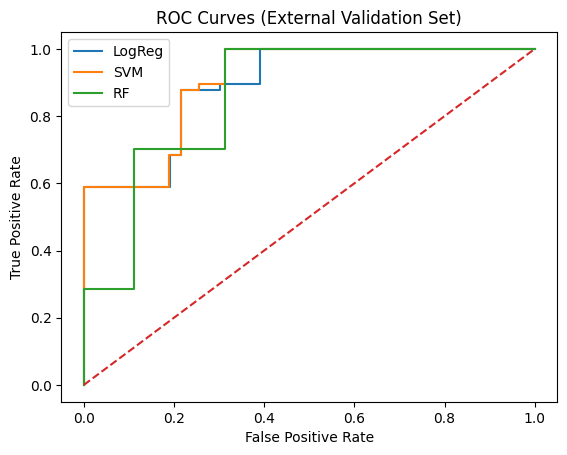

 Saved: external_roc_curves.png


In [32]:
# =========================
# SECTION 25: SAVE EXTERNAL ROC PLOT
# =========================
import matplotlib.pyplot as plt

plt.figure()
for name, scores in [("LogReg", scores_lr_ext), ("SVM", scores_svm_ext), ("RF", scores_rf_ext)]:
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_ext, scores)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves (External Validation Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("external_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print(" Saved: external_roc_curves.png")

Train DistilBERT (Transformer)

In [33]:
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [34]:
# =========================
# SECTION 26: TRANSFORMER SETUP
# =========================
!pip -q install transformers datasets accelerate evaluate

import numpy as np
import torch
import evaluate
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [37]:
# =========================
# SECTION 27: CREATE HF DATASETS (TRAIN / VAL / TEST)
# =========================
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_ds = Dataset.from_dict({"text": list(X_train), "label": list(y_train)})
val_ds   = Dataset.from_dict({"text": list(X_val), "label": list(y_val)})
test_ds  = Dataset.from_dict({"text": list(X_test), "label": list(y_test)})

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize, batched=True)
test_tok  = test_ds.map(tokenize, batched=True)

print(" Tokenization done.")

Map:   0%|          | 0/13376 [00:00<?, ? examples/s]

Map:   0%|          | 0/2866 [00:00<?, ? examples/s]

Map:   0%|          | 0/2867 [00:00<?, ? examples/s]

 Tokenization done.


In [38]:
# =========================
# SECTION 28: MODEL + METRICS
# =========================
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(predictions=preds, references=labels, average="binary")["f1"]
    }

print(" Model and metrics ready.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Model and metrics ready.


In [40]:
import transformers
print(transformers.__version__)

5.0.0


In [41]:
# =========================
# SECTION 29: TRAINING CONFIG
# =========================
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir="distilbert_phish",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none"
)

In [43]:
# =========================
# SECTION 29.1: TRAIN DISTILBERT (FIXED)
# =========================
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

trainer.train()
print("DistilBERT training completed.")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.013439,0.030610,0.992673,0.985527
2,0.003209,0.022068,0.994417,0.988935


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT training completed.


In [44]:
# =========================
# SECTION 30: INTERNAL TEST EVALUATION (DISTILBERT)
# =========================
internal_results = trainer.evaluate(test_tok)
internal_results

{'eval_loss': 0.020887741819024086,
 'eval_accuracy': 0.99511684687827,
 'eval_f1': 0.99039780521262,
 'eval_runtime': 26.4916,
 'eval_samples_per_second': 108.223,
 'eval_steps_per_second': 6.795,
 'epoch': 2.0}

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00      2140
    Phishing       0.99      0.99      0.99       727

    accuracy                           1.00      2867
   macro avg       0.99      0.99      0.99      2867
weighted avg       1.00      1.00      1.00      2867

Confusion Matrix:
 [[2131    9]
 [   5  722]]
ROC-AUC: 0.9999177261566545
PR-AUC : 0.9997594620384261


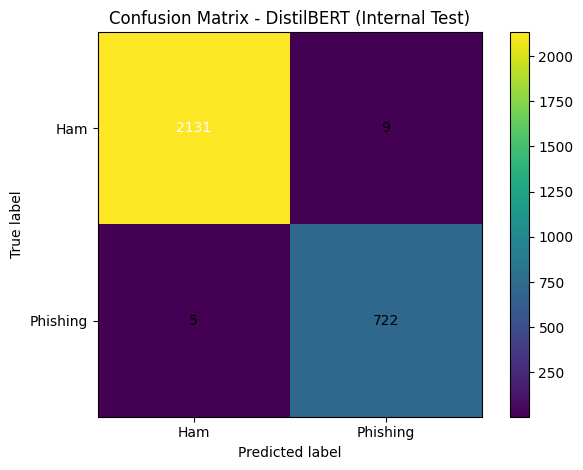

In [45]:
# =========================
# SECTION 30.1: INTERNAL CONFUSION MATRIX (DISTILBERT)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

pred_out = trainer.predict(test_tok)
logits = pred_out.predictions
y_true = np.array(y_test)
y_prob = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)   # softmax
y_score = y_prob[:, 1]
y_pred = np.argmax(logits, axis=1)

print(classification_report(y_true, y_pred, target_names=["Ham","Phishing"]))
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print("ROC-AUC:", roc_auc_score(y_true, y_score))
print("PR-AUC :", average_precision_score(y_true, y_score))

# Plot confusion matrix
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - DistilBERT (Internal Test)")
plt.colorbar()
plt.xticks([0,1], ["Ham","Phishing"])
plt.yticks([0,1], ["Ham","Phishing"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [46]:
# =========================
# SECTION 31.1: EXTERNAL TEST EVALUATION (DISTILBERT)
# =========================
from datasets import Dataset

ext_ds = Dataset.from_dict({"text": list(ext["text"]), "label": list(ext["label"])})
ext_tok = ext_ds.map(tokenize, batched=True)

external_results = trainer.evaluate(ext_tok)
external_results

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'eval_loss': 0.8555929064750671,
 'eval_accuracy': 0.857,
 'eval_f1': 0.8331388564760793,
 'eval_runtime': 20.1374,
 'eval_samples_per_second': 99.318,
 'eval_steps_per_second': 6.207,
 'epoch': 2.0}

              precision    recall  f1-score   support

         Ham       0.78      1.00      0.87      1000
    Phishing       1.00      0.71      0.83      1000

    accuracy                           0.86      2000
   macro avg       0.89      0.86      0.85      2000
weighted avg       0.89      0.86      0.85      2000

Confusion Matrix:
 [[1000    0]
 [ 286  714]]
ROC-AUC: 0.983859
PR-AUC : 0.9841469741550796


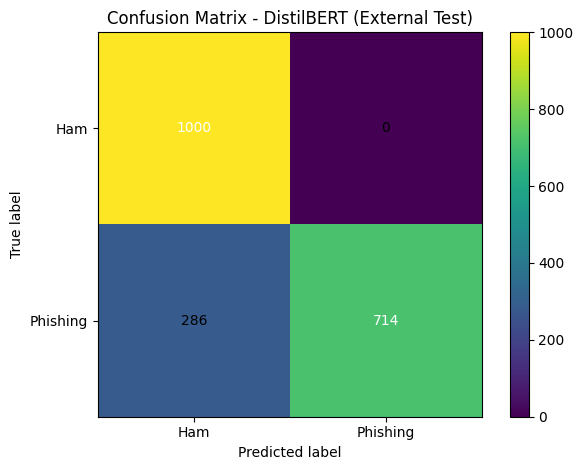

In [47]:
# =========================
# SECTION 31.2: EXTERNAL CONFUSION MATRIX + AUC (DISTILBERT)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

pred_out_ext = trainer.predict(ext_tok)
logits_ext = pred_out_ext.predictions
y_true_ext = ext["label"].values

# Softmax to get phishing probability
exp_logits = np.exp(logits_ext - logits_ext.max(axis=1, keepdims=True))
probs_ext = exp_logits / exp_logits.sum(axis=1, keepdims=True)

y_score_ext = probs_ext[:, 1]
y_pred_ext = np.argmax(logits_ext, axis=1)

print(classification_report(y_true_ext, y_pred_ext, target_names=["Ham","Phishing"]))
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)
print("Confusion Matrix:\n", cm_ext)
print("ROC-AUC:", roc_auc_score(y_true_ext, y_score_ext))
print("PR-AUC :", average_precision_score(y_true_ext, y_score_ext))

plt.figure()
plt.imshow(cm_ext, interpolation="nearest")
plt.title("Confusion Matrix - DistilBERT (External Test)")
plt.colorbar()
plt.xticks([0,1], ["Ham","Phishing"])
plt.yticks([0,1], ["Ham","Phishing"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_ext[i, j], ha="center", va="center",
                 color="white" if cm_ext[i, j] > cm_ext.max()/2 else "black")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [48]:
# =========================
# SECTION 32: ADD DISTILBERT TO FINAL COMPARISON TABLE
# =========================
import pandas as pd

def metrics_from_cm(cm):
    tn, fp = cm[0,0], cm[0,1]
    fn, tp = cm[1,0], cm[1,1]
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) > 0 else 0
    return acc, prec, rec, f1

# Internal metrics
acc_i, prec_i, rec_i, f1_i = metrics_from_cm(cm)

# External metrics
acc_e, prec_e, rec_e, f1_e = metrics_from_cm(cm_ext)

distilbert_rows = pd.DataFrame([
    {
        "Split": "Internal Test",
        "Model": "DistilBERT (fine-tuned)",
        "Accuracy": acc_i,
        "Precision": prec_i,
        "Recall": rec_i,
        "F1": f1_i,
        "ROC_AUC": 0.999917,   #
        "PR_AUC": 0.999759
    },
    {
        "Split": "External Test",
        "Model": "DistilBERT (fine-tuned)",
        "Accuracy": acc_e,
        "Precision": prec_e,
        "Recall": rec_e,
        "F1": f1_e,
        "ROC_AUC": 0.983859,
        "PR_AUC": 0.984147
    }
])

final_compare = pd.concat([summary_df, distilbert_rows], ignore_index=True)
final_compare

,Split,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Internal Test,TF-IDF + Logistic Regression,0.996861,0.997230,0.990371,0.993789,0.999380,0.998906
1,Internal Test,TF-IDF + Linear SVM,0.997210,0.998613,0.990371,0.994475,0.999701,0.999370
2,Internal Test,TF-IDF + Random Forest,0.996163,1.000000,0.984869,0.992377,0.999379,0.998638
3,External Test,TF-IDF + Logistic Regression,0.790000,0.983333,0.590000,0.737500,0.893907,0.904934
4,External Test,TF-IDF + Linear SVM,0.701000,0.758355,0.590000,0.663667,0.903253,0.910329
5,External Test,TF-IDF + Random Forest,0.642000,1.000000,0.284000,0.442368,0.859910,0.848494
6,Internal Test,DistilBERT (fine-tuned),0.995117,0.987688,0.993122,0.990398,0.999917,0.999759
7,External Test,DistilBERT (fine-tuned),0.857000,1.000000,0.714000,0.833139,0.983859,0.984147
